In [164]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
%matplotlib inline

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [144]:
df = pd.read_csv(r'C:\Users\User\Desktop\Проект CaseBridge\freelance_tasks_final - freelance_tasks_final.csv')
df.head()

,id,наименование_задачи,тип_задачи,технологический_стек,срок_выполнения_дней,цена_руб,ценовой_диапазон
0,1,Синхронизация CRM и 1С,Автоматизация и скрипты,Zapier+Python,14,7000,5 000–15 000 ₽
1,2,Приложение учёта финансов,Мобильное приложение,Flutter,31,33200,30 000–60 000 ₽
2,3,Приложение трекинга тренировок,Мобильное приложение,React Native+Redux,10,70000,60 000–120 000 ₽
3,4,Вёрстка личного кабинета,Вёрстка,HTML+CSS+BEM,12,3500,до 5 000 ₽
4,5,Каталог с корзиной на Flutter,Мобильное приложение,React Native+TS,40,69000,60 000–120 000 ₽


In [145]:
df.describe()

,id,срок_выполнения_дней,цена_руб
count,3000.000000,3000.000000,3000.000000
mean,1500.500000,13.062667,18362.000000
std,866.169729,11.737404,20184.316309
min,1.000000,1.000000,2000.000000
25%,750.750000,5.000000,6000.000000
50%,1500.500000,10.000000,10000.000000
75%,2250.250000,16.000000,20725.000000
max,3000.000000,60.000000,136500.000000


In [146]:
#ОЧИСТКА ЗНАЧЕНИЙ
print("Пропущенные значения")
print(df.isnull().sum())
print("\n Процент недостающих значений: ")
print((df.isnull().sum() / len(df) * 100).round(2) )

# Общие дубликаты
print("Полных дублирующихся строк:", df.duplicated().sum(),"\n")

print(df.dtypes)

df.shape

Пропущенные значения
id                      0
наименование_задачи     0
тип_задачи              0
технологический_стек    0
срок_выполнения_дней    0
цена_руб                0
ценовой_диапазон        0
dtype: int64

 Процент недостающих значений: 
id                      0.0
наименование_задачи     0.0
тип_задачи              0.0
технологический_стек    0.0
срок_выполнения_дней    0.0
цена_руб                0.0
ценовой_диапазон        0.0
dtype: float64
Полных дублирующихся строк: 0 

id                      int64
наименование_задачи       str
тип_задачи                str
технологический_стек      str
срок_выполнения_дней    int64
цена_руб                int64
ценовой_диапазон          str
dtype: object


(3000, 7)

<Axes: xlabel='цена_руб', ylabel='Count'>

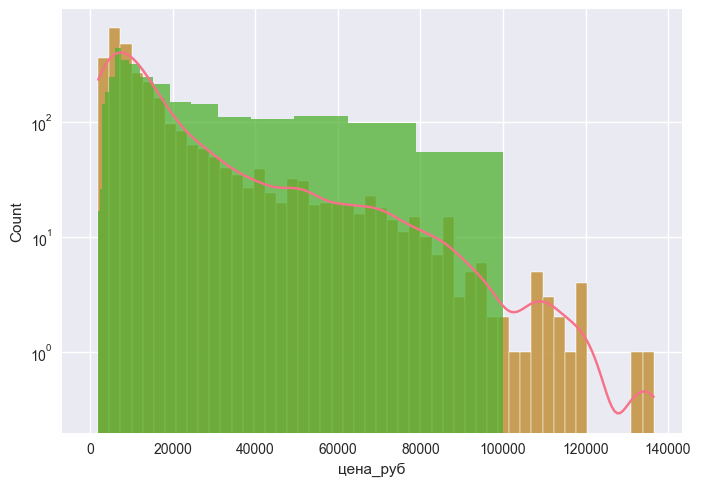

In [147]:
sns.histplot(data = df, x = "цена_руб", bins = 50, kde = True)

ax = sns.histplot(df['цена_руб'], bins = 50)
ax.set_yscale('log')

sns.histplot(df['цена_руб'], bins = np.logspace(0, 5, 50))

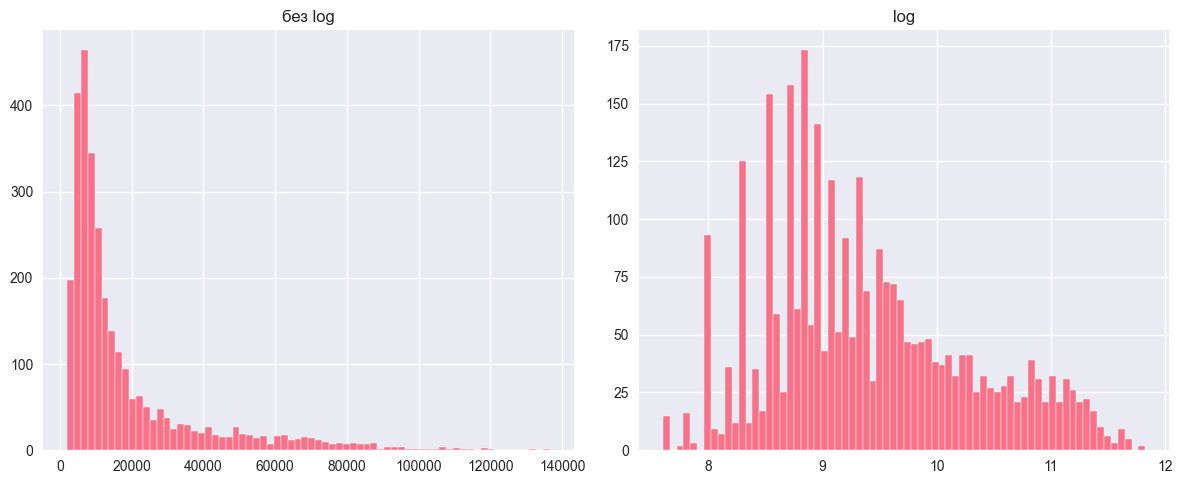

In [148]:
fig, axes = plt.subplots(1, 2, figsize = (12, 5))
axes[0].hist(df["цена_руб"], bins = 70)
axes[1].hist(np.log(df["цена_руб"]), bins = 70)
axes[0].set_title("без log")
axes[1].set_title("log")
plt.tight_layout()
plt.show()

<Axes: ylabel='тип_задачи'>

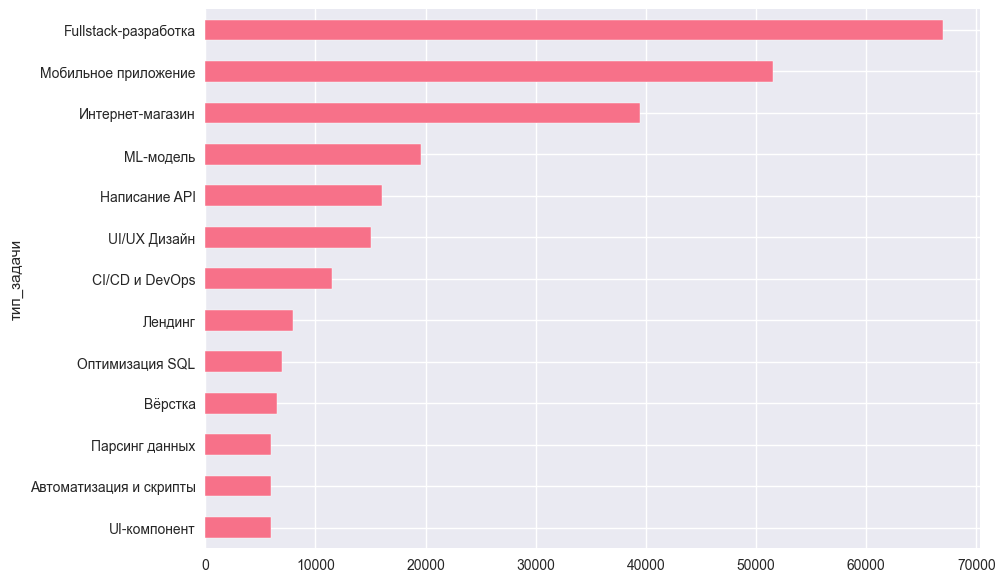

In [149]:
#медиана
med = df.groupby("тип_задачи")["цена_руб"].median()
med.sort_values().plot(kind="barh", figsize=(10, 7))


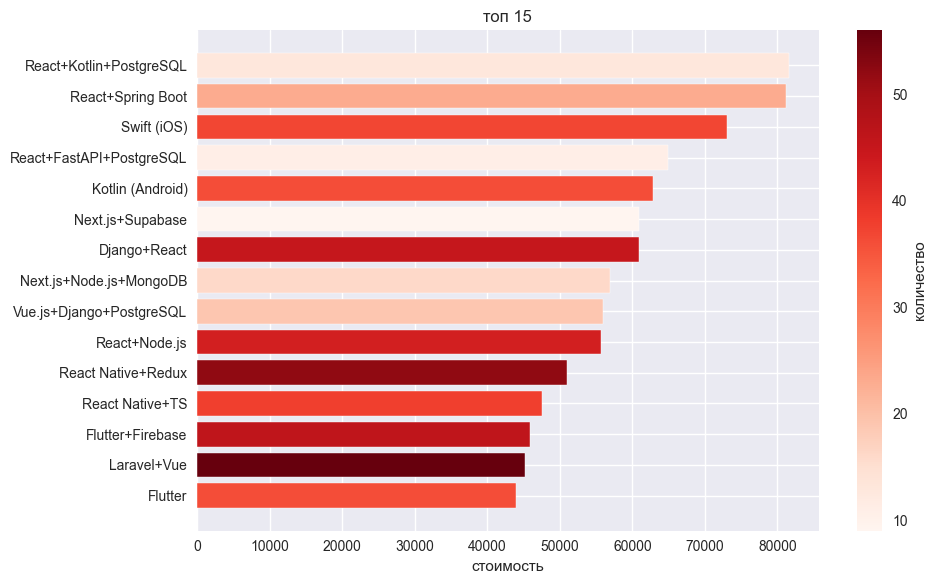

In [150]:
#df.groupby("технологический_стек")["цена_руб"].mean().sort_values(ascending=0).head(15)
group = df.groupby("технологический_стек")["цена_руб"].agg(["mean", "count"])
top15 = group.sort_values("mean", ascending=0).head(15)
top15 = top15.reset_index()

norm = matplotlib.colors.Normalize(vmin=top15["count"].min(), vmax=top15["count"].max())
palette = plt.colormaps["Reds"]
colors = palette(norm(top15["count"]))

fig, ax = plt.subplots(figsize = (10, 6))
ax.barh(y = range(len(top15)), width = top15["mean"], color = colors)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["технологический_стек"])
ax.invert_yaxis()

sm = plt.cm.ScalarMappable(norm=norm, cmap=palette)
fig.colorbar(sm, ax=ax, label="количество")

ax.set_xlabel("стоимость")
ax.set_title("топ 15")
plt.tight_layout()
plt.show()


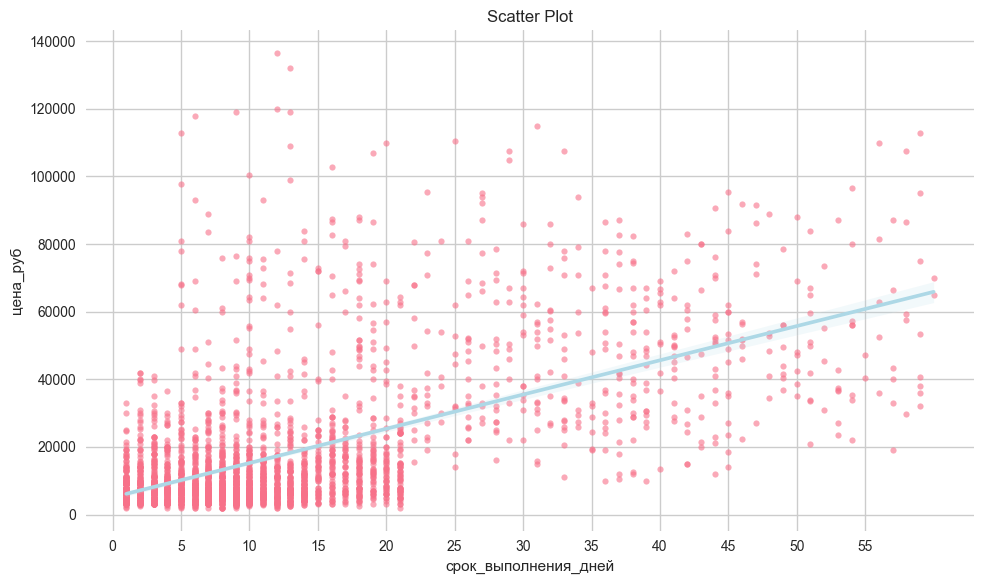

Correlation = 0.450
p-value = 2.3895e-149


In [151]:

sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="срок_выполнения_дней",
    y="цена_руб",
    scatter_kws={"s": 20, "alpha": 0.6},
    line_kws={"color": "lightblue"}
)
plt.xticks(np.arange(0, 60, 5))
plt.title("Scatter Plot")
plt.tight_layout()
plt.show()

from scipy.stats import spearmanr

corr, p = spearmanr(df["срок_выполнения_дней"], df["цена_руб"])

print(f"Correlation = {corr:.3f}")
print(f"p-value = {p:.5}")

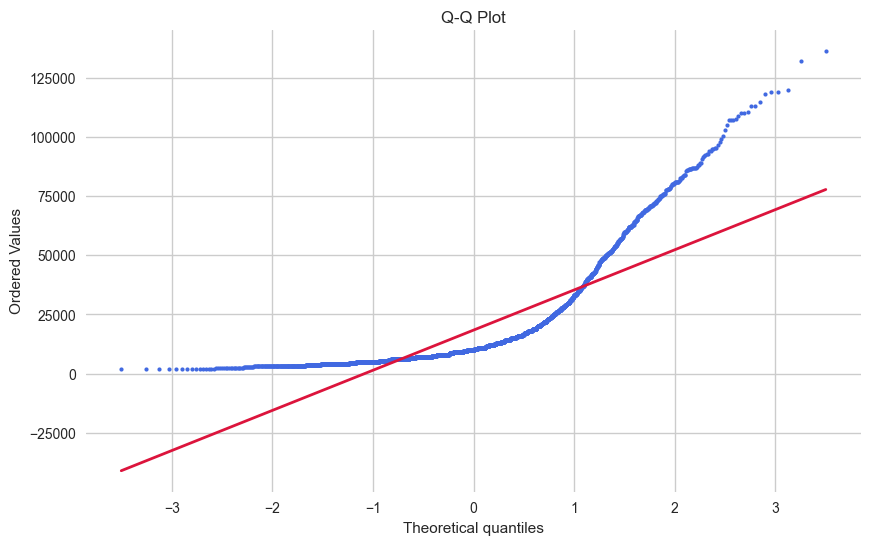

In [152]:
fig, ax = plt.subplots(figsize=(10, 6))

stats.probplot(df["цена_руб"], dist="norm", plot=ax)

ax.get_lines()[0].set_markersize(3)
ax.get_lines()[0].set_markerfacecolor("royalblue")
ax.get_lines()[0].set_markeredgecolor("royalblue")

ax.get_lines()[1].set_color("crimson")
ax.get_lines()[1].set_linewidth(2)

plt.title("Q-Q Plot")
plt.show()

In [167]:
#3
df_model = df.drop(columns=["id", "ценовой_диапазон", "наименование_задачи"]).copy()

df_model["цена_руб"] = np.log(df_model["цена_руб"])

df_model = pd.get_dummies(df_model, drop_first=True)

X = df_model.drop("цена_руб", axis=1)
Y = df_model["цена_руб"]

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

In [168]:
linear = LinearRegression()
linear.fit(X_train, Y_train)
# Предсказания в рублях
Y_pred_lin_real = np.exp(linear.predict(X_test))

# Истинные значения в рублях
Y_test_real = np.exp(Y_test)

mae_lin = mean_absolute_error(Y_test_real, Y_pred_lin_real)
r2_lin = r2_score(Y_test_real, Y_pred_lin_real)


forest = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

forest.fit(X_train, Y_train)
Y_pred_forest_real = np.exp(forest.predict(X_test))

mae_forest = mean_absolute_error(Y_test_real, Y_pred_forest_real)
r2_forest = r2_score(Y_test_real, Y_pred_forest_real)

results = pd.DataFrame({
    "Модель": ["Linear Regression", "Random Forest"],
    "MAE (руб.)": [mae_lin, mae_forest],
    "R^2": [r2_lin, r2_forest]
})

print(results)





              Модель   MAE (руб.)       R^2
0  Linear Regression  5831.303951  0.790260
1      Random Forest  6129.050504  0.744251


In [176]:
df_class = df.copy()

df_class["ценовой_диапазон"] = df_class["ценовой_диапазон"].replace({
    "свыше 120 000 ₽": "60 000+ ₽"
})

df_class["ценовой_диапазон"] = df_class["ценовой_диапазон"].replace({
    "60 000–120 000 ₽": "60 000+ ₽"
})

print(df_class["ценовой_диапазон"].value_counts())

y_cls = df_class["ценовой_диапазон"]

df_class = df_class.drop(columns=[
    "id",
    "наименование_задачи",
    "цена_руб",
    "ценовой_диапазон"
])

X = pd.get_dummies(X, drop_first=True)


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

ценовой_диапазон
5 000–15 000 ₽     1560
15 000–30 000 ₽     535
до 5 000 ₽          382
30 000–60 000 ₽     323
60 000+ ₽           200
Name: count, dtype: int64


In [177]:
classifier = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)

classifier.fit(X_train,y_train)
y_pred = classifier.predict(X_test)
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

15 000–30 000 ₽       0.43      0.57      0.49       107
30 000–60 000 ₽       0.47      0.48      0.47        65
 5 000–15 000 ₽       0.80      0.52      0.63       312
      60 000+ ₽       0.41      0.47      0.44        40
     до 5 000 ₽       0.39      0.72      0.51        76

       accuracy                           0.55       600
      macro avg       0.50      0.55      0.51       600
   weighted avg       0.62      0.55      0.56       600



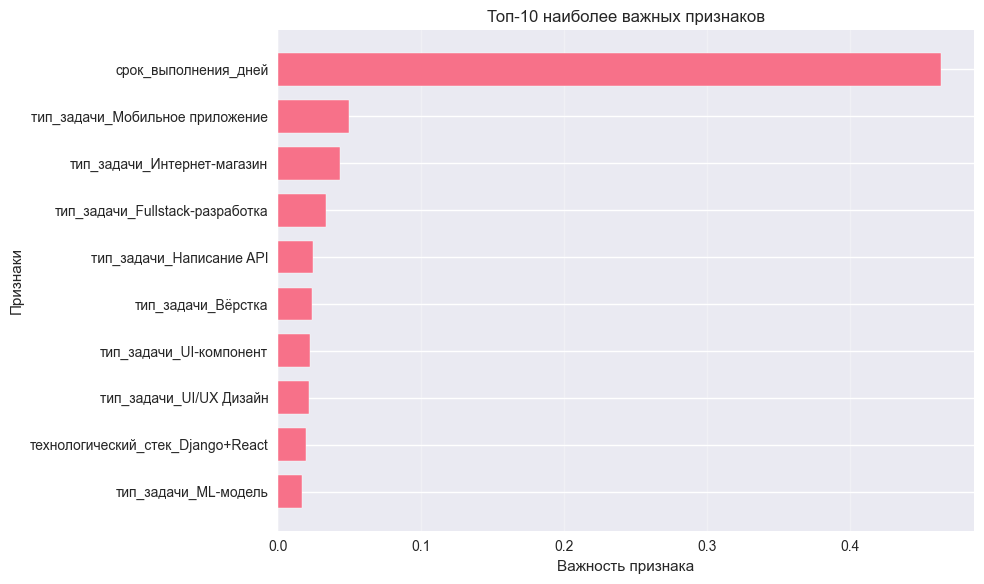

                                Признак  Важность
0                  срок_выполнения_дней  0.463448
9       тип_задачи_Мобильное приложение  0.049631
7           тип_задачи_Интернет-магазин  0.043210
1       тип_задачи_Fullstack-разработка  0.033268
10             тип_задачи_Написание API  0.024446
..                                  ...       ...
14         технологический_стек_Angular  0.000824
71      технологический_стек_SQL Server  0.000800
69  технологический_стек_React+Tailwind  0.000757
17        технологический_стек_BigQuery  0.000716
18      технологический_стек_ClickHouse  0.000685

[89 rows x 2 columns]


In [179]:
#6

importance = pd.DataFrame({
    "Признак": X_train.columns,
    "Важность": classifier.feature_importances_
})

importance = importance.sort_values(
    by="Важность",
    ascending=False
)

top10 = importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top10["Признак"],
    top10["Важность"],
    height=0.7
)

plt.gca().invert_yaxis()

plt.title("Топ-10 наиболее важных признаков")
plt.xlabel("Важность признака")
plt.ylabel("Признаки")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()
print(importance)